<a href="https://colab.research.google.com/github/snehasawant054-design/CSL701-CE-43_Machine-Learning-Lab./blob/main/Experiments/Experiment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sneha Baburao Sawant
Roll no: CE-43

### Aim : To implement a **Logistic Regression** model to classify credit card transactions as **fraudulent or legitimate**.


## Objectives

1. To understand the mathematical foundations of **Logistic Regression** and the **Sigmoid Function**.
2. To understand and handle **class imbalance** in credit card fraud datasets.
3. To implement **Gradient Descent** for optimizing Logistic Regression parameters.
4. To evaluate the model using **Confusion Matrix, Precision, Recall, F1-Score, ROC Curve, and AUC**.
5. To understand the importance of **Recall and False Negative Rate** in fraud detection.


## Relevant Theory

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for **binary classification**. In this experiment, it is used to classify credit card transactions into two classes:

- **0 $\rightarrow$ Legitimate transaction**
- **1 $\rightarrow$ Fraudulent transaction**

The model first calculates a linear combination of input features:

$$
z = w^T X + b
$$

where:

- $w$ = weight vector
- $X$ = input feature vector
- $b$ = bias/intercept
- $z$ = linear predictor

---

### Sigmoid Function

The Sigmoid Function converts the value of $z$ into a probability between 0 and 1:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

The predicted probability that a transaction is fraudulent is:

$$
P(y=1|X) = \sigma(w^T X + b)
$$

The predicted class can be obtained using a threshold:

$$
\hat{y} =
\begin{cases}
1, & \text{if } P(y=1|X) \geq 0.5 \\
0, & \text{if } P(y=1|X) < 0.5
\end{cases}
$$

---
## Cost Function

Logistic Regression uses the **Binary Cross-Entropy Loss** or **Log Loss**.

The cost function is:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i \log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

- $m$ = number of training examples
- $y_i$ = actual class label
- $\hat{y}_i$ = predicted probability

The objective of training is to find values of $w$ and $b$ that minimize the cost function.

---

## Gradient Descent

Gradient Descent is used to optimize the parameters of the Logistic Regression model.

The weights are updated using:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

The bias is updated using:

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

For Logistic Regression, the gradient of the cost function with respect to the weights can be expressed as:

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

The gradient with respect to the bias is:

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
$$

Therefore, the parameter updates become:

$$
w := w - \alpha
\left[
\frac{1}{m}X^T(\hat{y}-y)
\right]
$$

$$
b := b - \alpha
\left[
\frac{1}{m}
\sum_{i=1}^{m}
(\hat{y}_i-y_i)
\right]
$$

---

## Class Imbalance

Credit card fraud datasets are generally highly imbalanced because legitimate transactions significantly outnumber fraudulent transactions.

For example, the dataset may contain a very large number of legitimate transactions and only a small number of fraudulent transactions.

A model that predicts most transactions as legitimate may achieve high accuracy but perform poorly at detecting fraud.

Therefore, techniques such as:

- Random Undersampling
- Oversampling
- Class Weighting

can be used to handle class imbalance.

---

## Evaluation Metrics

### Confusion Matrix

The confusion matrix consists of four components:

- **True Positive (TP):** Fraudulent transaction correctly identified as fraud.
- **True Negative (TN):** Legitimate transaction correctly identified as legitimate.
- **False Positive (FP):** Legitimate transaction incorrectly identified as fraud.
- **False Negative (FN):** Fraudulent transaction incorrectly identified as legitimate.

---

### Accuracy

Accuracy measures the proportion of correctly classified transactions:

$$
Accuracy =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

However, accuracy alone is not sufficient for highly imbalanced fraud detection datasets.

---

### Precision

Precision indicates the proportion of transactions predicted as fraudulent that are actually fraudulent:

$$
Precision =
\frac{TP}
{TP+FP}
$$

A high Precision means that the model produces fewer false fraud alerts.

---

### Recall

Recall measures the proportion of actual fraudulent transactions correctly detected:

$$
Recall =
\frac{TP}
{TP+FN}
$$

Recall is particularly important in fraud detection because a **False Negative** represents a fraudulent transaction that was not detected.

---

### F1-Score

F1-Score is the harmonic mean of Precision and Recall:

$$
F1 =
2 \times
\frac{Precision \times Recall}
{Precision + Recall}
$$

---

## ROC Curve

The Receiver Operating Characteristic (ROC) curve represents the relationship between the **True Positive Rate (TPR)** and **False Positive Rate (FPR)** at different classification thresholds.

The True Positive Rate is:

$$
TPR =
\frac{TP}
{TP+FN}
$$

The False Positive Rate is:

$$
FPR =
\frac{FP}
{FP+TN}
$$

The ROC curve helps determine how well the model separates fraudulent transactions from legitimate transactions.

---

## *Area Under the Curve (AUC)*

The **Area Under the ROC Curve (AUC)** summarizes the performance of the classifier across different classification thresholds.

An AUC value close to:

$$
AUC = 1
$$

indicates excellent discrimination, while:

$$
AUC = 0.5
$$

indicates performance approximately equivalent to random classification.

---

### Dataset Information

The Credit Card Fraud Dataset contains transaction-related features such as transaction amount, distance from home, purchase-price-related ratios, and transaction characteristics.

The target variable is fraud:


0 → Legitimate transaction

1 → Fraudulent transaction

---

In [ ]:
# ==============================
# TASK 1: ENVIRONMENT SETUP
# ==============================

from google.colab import files
import zipfile
import os

uploaded = files.upload()

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, "r") as zip_ref:
    zip_ref.extractall("/content")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score,
    roc_curve, roc_auc_score
)

df = pd.read_csv("card_transdata.csv")

print("First 5 records:")
display(df.head())

print("\nShape of dataset:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nDescriptive statistics:")
display(df.describe())

target = "fraud"

X = df.drop(columns=[target])
y = df[target]

print("\nFeature variables:")
print(X.columns.tolist())

print("\nTarget variable:")
print(target)

print("\nClass distribution:")
print(y.value_counts())

class_percentage = y.value_counts(normalize=True) * 100

print("\nClass percentages:")
print(class_percentage)

Saving archive.zip to archive.zip
First 5 records:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,57.877857,0.311140,1.945940,1.0,1.0,0.0,0.0,0.0
1,10.829943,0.175592,1.294219,1.0,0.0,0.0,0.0,0.0
2,5.091079,0.805153,0.427715,1.0,0.0,0.0,1.0,0.0
3,2.247564,5.600044,0.362663,1.0,1.0,0.0,1.0,0.0
4,44.190936,0.566486,2.222767,1.0,1.0,0.0,1.0,0.0



Shape of dataset:
(1000000, 8)

Column names:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order', 'fraud']

Data types:
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

Descriptive statistics:


,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,26.628792,5.036519,1.824182,0.881536,0.350399,0.100608,0.650552,0.087403
std,65.390784,25.843093,2.799589,0.323157,0.477095,0.300809,0.476796,0.282425
min,0.004874,0.000118,0.004399,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.878008,0.296671,0.475673,1.000000,0.000000,0.000000,0.000000,0.000000
50%,9.967760,0.998650,0.997717,1.000000,0.000000,0.000000,1.000000,0.000000
75%,25.743985,3.355748,2.096370,1.000000,1.000000,0.000000,1.000000,0.000000
max,10632.723672,11851.104565,267.802942,1.000000,1.000000,1.000000,1.000000,1.000000



Feature variables:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Target variable:
fraud

Class distribution:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

Class percentages:
fraud
0.0    91.2597
1.0     8.7403
Name: proportion, dtype: float64


## Task 2: Perform Exploratory Data Analysis

Perform **Exploratory Data Analysis (EDA)** to understand the structure, distribution, and characteristics of the Credit Card Fraud Dataset.

Calculate and display the following:

* Number of **legitimate transactions**.
* Number of **fraudulent transactions**.
* Percentage of legitimate transactions.
* Percentage of fraudulent transactions.
* Distribution of numerical features.

The percentage of each class can be calculated using:
$$
\text{Class Percentage} =
\frac{\text{Number of Transactions in Class}}
{\text{Total Number of Transactions}}
\times 100
$$

Plot the **class distribution** using a suitable visualization such as a bar chart.

Analyze the class distribution and explain the problem of **classification imbalance** in credit card fraud detection.

A dataset is considered highly imbalanced when the number of legitimate transactions is significantly greater than the number of fraudulent transactions. Therefore, accuracy alone may not be sufficient to evaluate the performance of the fraud detection model.


Legitimate transactions: 912597
Fraudulent transactions: 87403

Percentage of legitimate transactions: 91.2597
Percentage of fraudulent transactions: 8.7403


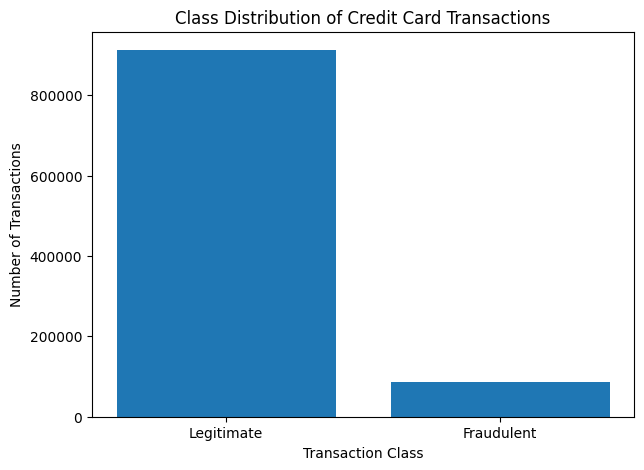

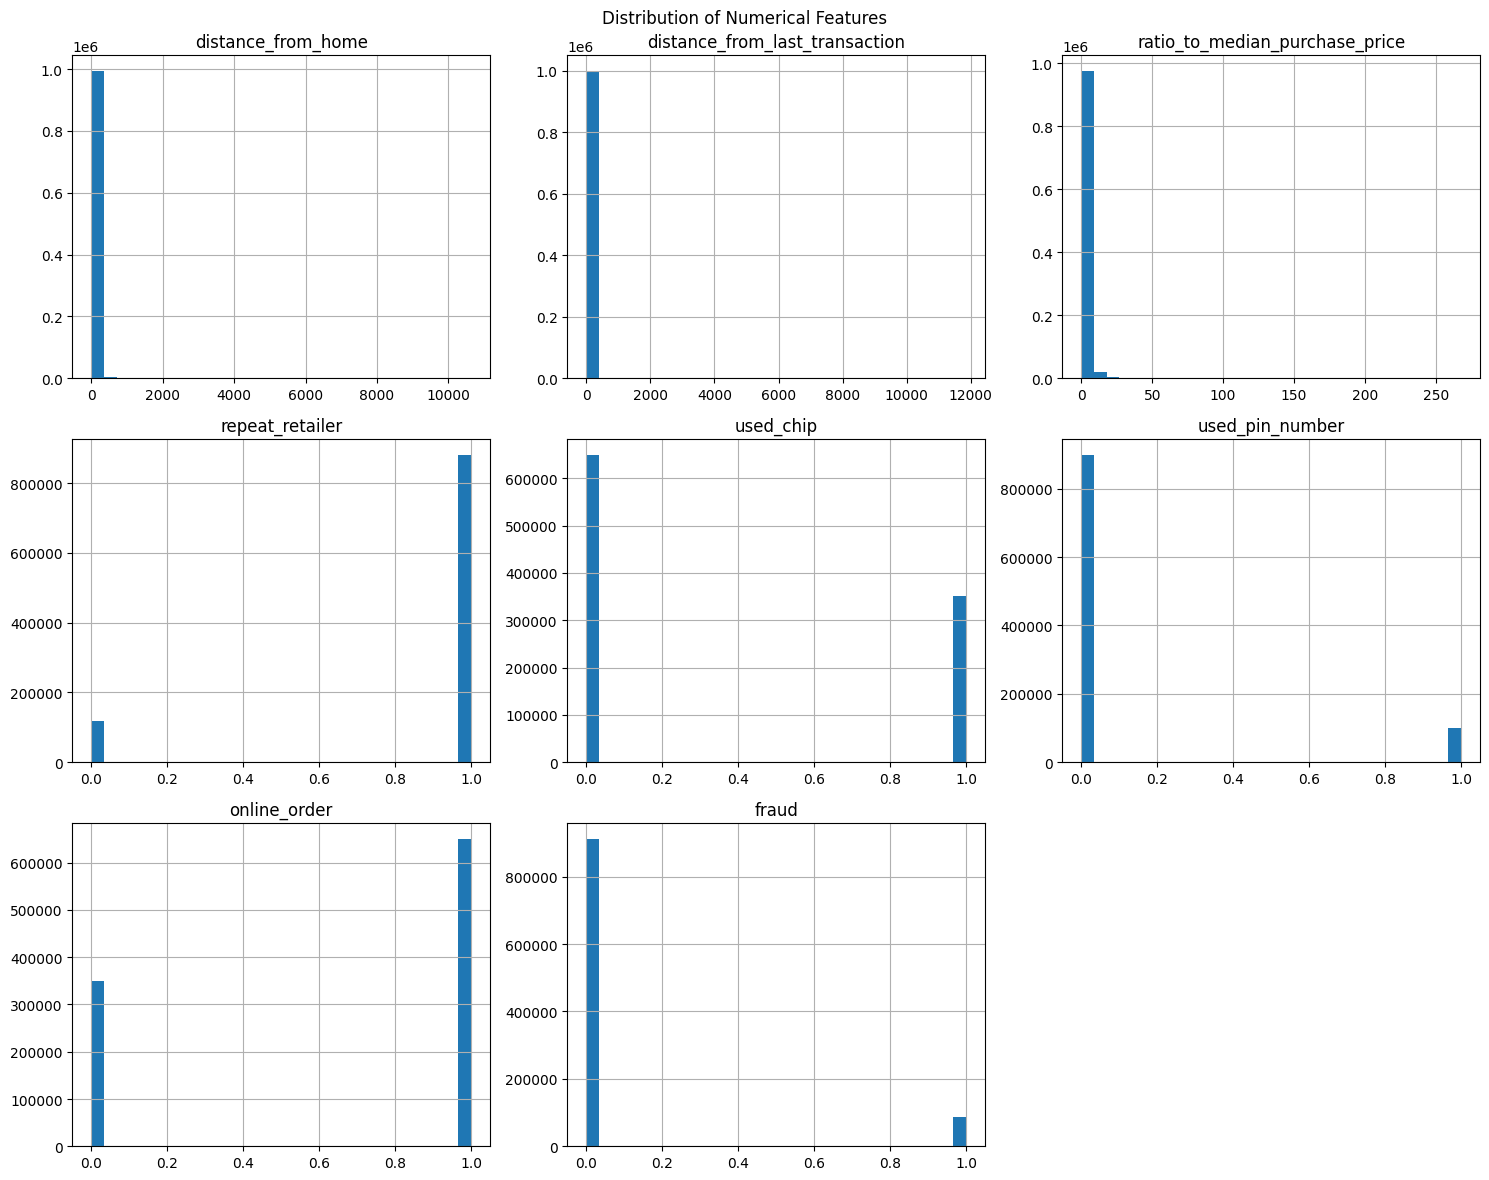

In [ ]:
# ==============================
# TASK 2: EXPLORATORY DATA ANALYSIS
# ==============================

legitimate = (y == 0).sum()
fraudulent = (y == 1).sum()
total = len(y)

legitimate_percentage = legitimate / total * 100
fraudulent_percentage = fraudulent / total * 100

print("Legitimate transactions:", legitimate)
print("Fraudulent transactions:", fraudulent)

print("\nPercentage of legitimate transactions:", legitimate_percentage)
print("Percentage of fraudulent transactions:", fraudulent_percentage)

plt.figure(figsize=(7, 5))

counts = y.value_counts().sort_index()

plt.bar(["Legitimate", "Fraudulent"], counts.values)

plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.title("Class Distribution of Credit Card Transactions")

plt.show()

df.hist(figsize=(15, 12), bins=30)

plt.suptitle("Distribution of Numerical Features")

plt.tight_layout()

plt.show()

## Task 3: Data Preprocessing

Check the dataset for the following:

* Missing values.
* Duplicate records.
* Categorical variables.
* Numerical variables.

Identify the number of missing values in each column and handle them using suitable techniques such as **removal or imputation**.

Identify categorical variables and convert them into numerical form using appropriate **encoding techniques**.

For example, categorical variables can be converted into numerical values using **One-Hot Encoding**.

Also, identify the numerical features that will be used for building the Logistic Regression model.

The objective of this task is to prepare a clean and suitable dataset for further processing, feature scaling, model training, and evaluation.


In [ ]:
# ==============================
# TASK 3: DATA PREPROCESSING
# ==============================

print("Missing values in each column:")
print(df.isnull().sum())

numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

for col in numerical_columns:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_columns:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Number of duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

X = df.drop(columns=["fraud"])
y = df["fraud"]

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

if len(categorical_columns) > 0:
    X = pd.get_dummies(
        X,
        columns=categorical_columns,
        drop_first=True
    )

    print("Shape after encoding:", X.shape)

Missing values in each column:
distance_from_home                0
distance_from_last_transaction    0
ratio_to_median_purchase_price    0
repeat_retailer                   0
used_chip                         0
used_pin_number                   0
online_order                      0
fraud                             0
dtype: int64

Numerical columns:
['distance_from_home', 'distance_from_last_transaction', 'ratio_to_median_purchase_price', 'repeat_retailer', 'used_chip', 'used_pin_number', 'online_order']

Categorical columns:
[]
Number of duplicate rows: 0
Shape after removing duplicates: (1000000, 8)


## Task 4: Feature Scaling and Class Imbalance Handling

Standardize the numerical features using **Standardization** so that they have approximately zero mean and unit variance.

The standardized value of a feature is calculated as:

$$
z = \frac{x-\mu}{\sigma}
$$

where:

* (x) = original feature value
* (\mu) = mean of the feature
* (\sigma) = standard deviation of the feature
* (z) = standardized feature value

Handle the **class imbalance** in the dataset using a suitable technique such as:

* Random Undersampling
* Oversampling
* Class Weighting

Display the class distribution **before and after** applying the selected class-imbalance handling technique.

Compare the number of legitimate and fraudulent transactions before and after balancing.

The objective of this task is to ensure that the features are on a comparable scale and that the Logistic Regression model does not become biased toward the majority class.


In [ ]:
# ==============================
# TASK 4: CLASS IMBALANCE
# ==============================

print("Original class distribution:")
print(y.value_counts())

train_data = X.copy()
train_data["fraud"] = y.values

legitimate_data = train_data[train_data["fraud"] == 0]
fraud_data = train_data[train_data["fraud"] == 1]

print("Before balancing:")
print(train_data["fraud"].value_counts())

n_fraud = len(fraud_data)

legitimate_sample = legitimate_data.sample(
    n=n_fraud,
    random_state=42
)

balanced_data = pd.concat([
    legitimate_sample,
    fraud_data
])

balanced_data = balanced_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_balanced = balanced_data.drop(columns=["fraud"])
y_balanced = balanced_data["fraud"]

print("\nAfter balancing:")
print(y_balanced.value_counts())


# ==============================
# TASK 4: FEATURE SCALING
# ==============================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_balanced)

X_val_scaled = scaler.transform(X_val)

X_test_scaled = scaler.transform(X_test)

print("\nShape of scaled training data:", X_train_scaled.shape)
print("Shape of scaled validation data:", X_val_scaled.shape)
print("Shape of scaled test data:", X_test_scaled.shape)

Original class distribution:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64
Before balancing:
fraud
0.0    912597
1.0     87403
Name: count, dtype: int64

After balancing:
fraud
0.0    87403
1.0    87403
Name: count, dtype: int64

Shape of scaled training data: (104884, 7)
Shape of scaled validation data: (200000, 7)
Shape of scaled test data: (200000, 7)


## Task 5: Split the Dataset

Divide the preprocessed dataset into three subsets:

* **Training Set -- 60%**
* **Validation Set -- 20%**
* **Test Set -- 20%**

Use **stratified splitting** to maintain a representative proportion of fraudulent and legitimate transactions in each subset.

The dataset should first be divided into training and temporary sets. The temporary set should then be divided equally into validation and test sets.

The objective of this task is to use the training set for model training, the validation set for model evaluation and parameter selection, and the test set for final performance evaluation.


In [ ]:
# ==============================
# TASK 5: TRAIN/VALIDATION/TEST SPLIT
# ==============================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

print("\nTraining distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

training_data = X_train.copy()
training_data["fraud"] = y_train.values

train_legitimate = training_data[
    training_data["fraud"] == 0
]

train_fraud = training_data[
    training_data["fraud"] == 1
]

train_legitimate_sample = train_legitimate.sample(
    n=len(train_fraud),
    random_state=42
)

balanced_train = pd.concat([
    train_legitimate_sample,
    train_fraud
])

balanced_train = balanced_train.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

X_train_balanced = balanced_train.drop(
    columns=["fraud"]
)

y_train_balanced = balanced_train["fraud"]

print("Balanced training distribution:")
print(y_train_balanced.value_counts())

Training set: (600000, 7)
Validation set: (200000, 7)
Test set: (200000, 7)

Training distribution:
fraud
0.0    547558
1.0     52442
Name: count, dtype: int64

Validation distribution:
fraud
0.0    182519
1.0     17481
Name: count, dtype: int64

Test distribution:
fraud
0.0    182520
1.0     17480
Name: count, dtype: int64
Balanced training distribution:
fraud
0.0    52442
1.0    52442
Name: count, dtype: int64


## Task 6: Implement Sigmoid and Cost Functions

Implement the **Sigmoid Function** used in Logistic Regression.

The Sigmoid Function is defined as:

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

The Sigmoid Function converts the output of the linear equation into a probability value between 0 and 1.

Implement the **Binary Cross-Entropy Cost Function**:

$$
J(w,b) =
-\frac{1}{m}
\sum_{i=1}^{m}
\left[
y_i\log(\hat{y}_i)
+
(1-y_i)\log(1-\hat{y}_i)
\right]
$$

where:

* (m) = number of training samples
* (y_i) = actual class label
* (\hat{y}_i) = predicted probability
* (w) = weight vector
* (b) = bias

Test the Sigmoid Function using suitable sample values.

Calculate the initial cost of the Logistic Regression model using the initialized weights and bias.

The objective of this task is to understand how the Sigmoid Function produces probabilities and how the Binary Cross-Entropy Cost Function measures the error of the Logistic Regression model.


In [ ]:
# ==============================
# TASK 6: SIGMOID AND COST FUNCTION
# ==============================

def sigmoid(z):
    # Prevent overflow in exponential
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


test_values = np.array([-5, -2, 0, 2, 5])

print("Input:")
print(test_values)

print("\nSigmoid output:")
print(sigmoid(test_values))


def compute_cost(X, y, w, b):

    m = len(y)

    z = np.dot(X, w) + b

    y_pred = sigmoid(z)

    epsilon = 1e-15

    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    cost = -(1 / m) * np.sum(
        y * np.log(y_pred) +
        (1 - y) * np.log(1 - y_pred)
    )

    return cost


n_features = X_train_scaled.shape[1]

w_initial = np.zeros(n_features)

b_initial = 0

initial_cost = compute_cost(
    X_train_scaled,
    y_train_balanced.values,
    w_initial,
    b_initial
)

print("\nInitial Cost:", initial_cost)

Input:
[-5 -2  0  2  5]

Sigmoid output:
[0.00669285 0.11920292 0.5        0.88079708 0.99330715]

Initial Cost: 0.6931471805599453


## Task 7: Implement Logistic Regression Using Gradient Descent

Implement **Logistic Regression from scratch** using NumPy without directly using the Scikit-learn Logistic Regression implementation.

Initialize the model parameters, including the **weight vector** (w) and **bias** (b).

Calculate the predicted probability using the Sigmoid Function:

$$
\hat{y} = \sigma(Xw+b)
$$

where:

* (X) = input feature matrix
* (w) = weight vector
* $\hat{y} = \text{predicted probability}$


Calculate the gradients of the cost function with respect to the weights and bias:

<div align="left">

$$
\frac{\partial J}{\partial w}
=
\frac{1}{m}X^T(\hat{y}-y)
$$

$$
\frac{\partial J}{\partial b}
=
\frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)
$$

</div>

Update the model parameters using **Gradient Descent**:

$$
w := w-\alpha\frac{\partial J}{\partial w}
$$

$$
b := b-\alpha\frac{\partial J}{\partial b}
$$

where ($\alpha$) represents the **learning rate**.

Train the model for a suitable number of iterations and record the cost value during each iteration.

Plot **Cost vs. Iteration** to verify whether the optimization process is converging.

The objective of this task is to implement Logistic Regression manually and understand how Gradient Descent optimizes the model parameters by minimizing the Binary Cross-Entropy Cost Function.


Iteration    0: Cost 0.6808
Iteration  100: Cost 0.3731
Iteration  200: Cost 0.3145
Iteration  300: Cost 0.2859
Iteration  400: Cost 0.2688
Iteration  500: Cost 0.2573
Iteration  600: Cost 0.2492
Iteration  700: Cost 0.2431
Iteration  800: Cost 0.2384
Iteration  900: Cost 0.2347
Iteration  999: Cost 0.2317

Final weights: [ 1.8867724   1.15774109  3.76832915 -0.25523053 -0.38124642 -1.15780879
  1.41214406]
Final bias: 0.2514589659900068


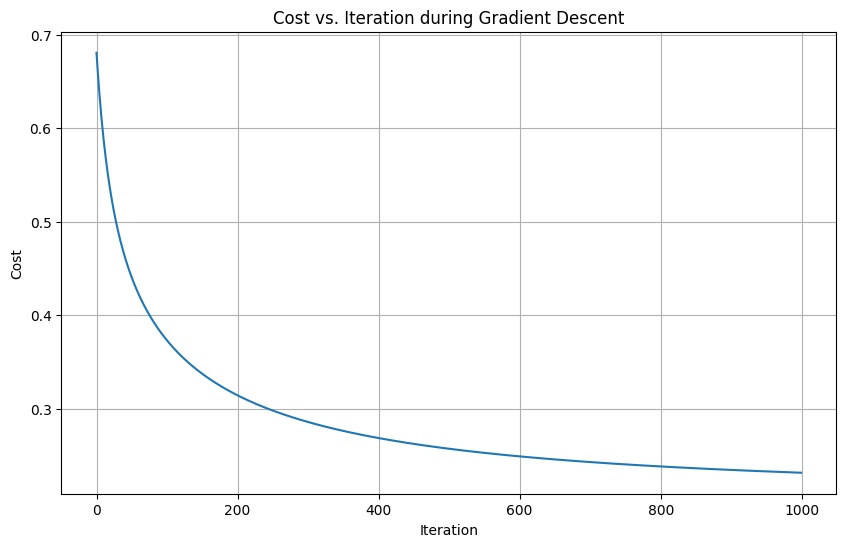

In [ ]:
# ==========================================
# TASK 7: IMPLEMENT LOGISTIC REGRESSION USING GRADIENT DESCENT
# ==========================================

def train_model(X, y, w_in, b_in, learning_rate, num_iterations):
    w = w_in
    b = b_in
    cost_history = []

    for i in range(num_iterations):
        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        m = len(y)

        dj_dw = (1 / m) * np.dot(X.T, (y_pred - y))
        dj_db = (1 / m) * np.sum(y_pred - y)

        w = w - learning_rate * dj_dw
        b = b - learning_rate * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % (num_iterations // 10) == 0 or i == num_iterations - 1:
            print(f"Iteration {i:4d}: Cost {cost:.4f}")

    return w, b, cost_history


learning_rate = 0.1
num_iterations = 1000

w_final, b_final, cost_history = train_model(
    X_train_scaled,
    y_train_balanced.values,
    w_initial,
    b_initial,
    learning_rate,
    num_iterations
)

print("\nFinal weights:", w_final)
print("Final bias:", b_final)

plt.figure(figsize=(10, 6))
plt.plot(cost_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost vs. Iteration during Gradient Descent")
plt.grid(True)
plt.show()

## Task 8: Generate Predictions and Evaluate the Confusion Matrix

Use the trained Logistic Regression model to calculate the **fraud probabilities** for the validation and test datasets.

The predicted probability is calculated using:

$$
\hat{y} = \sigma(Xw+b)
$$

Convert the predicted probabilities into class labels using a threshold of **0.5**:

$$
\hat{y}_{class} =
\begin{cases}
1, & \text{if } \hat{y} \geq 0.5 \
0, & \text{if } \hat{y} < 0.5
\end{cases}
$$

Construct the **Confusion Matrix** and identify the following:

* **True Positive (TP):** Fraudulent transactions correctly classified as fraudulent.
* **True Negative (TN):** Legitimate transactions correctly classified as legitimate.
* **False Positive (FP):** Legitimate transactions incorrectly classified as fraudulent.
* **False Negative (FN):** Fraudulent transactions incorrectly classified as legitimate.

The confusion matrix can be represented as:

$$
\text{Confusion Matrix} =
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

Explain the meaning of each result in the context of **credit card fraud detection**.

The objective of this task is to evaluate the classification results of the Logistic Regression model and understand the different types of prediction errors, with particular attention to **False Negatives**, which represent fraudulent transactions that are not detected.


In [ ]:
# ==========================================
# TASK 8: GENERATE PREDICTIONS AND EVALUATE THE CONFUSION MATRIX
# ==========================================

def predict_classes(X, w, b, threshold=0.5):
    probabilities = sigmoid(np.dot(X, w) + b)
    return (probabilities >= threshold).astype(int)


y_val_pred = predict_classes(X_val_scaled, w_final, b_final)
y_test_pred = predict_classes(X_test_scaled, w_final, b_final)

cm_val = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix for Validation Set:")
print(cm_val)

cm_test = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix for Test Set:")
print(cm_test)

TN_val, FP_val, FN_val, TP_val = cm_val.ravel()

print(f"\nValidation Set - True Negatives (TN): {TN_val}")
print(f"Validation Set - False Positives (FP): {FP_val}")
print(f"Validation Set - False Negatives (FN): {FN_val}")
print(f"Validation Set - True Positives (TP): {TP_val}")

print("\nInterpretation for Validation Set:")

print(" - True Positives (TP): Number of actual fraudulent transactions correctly identified as fraud.")
print(" - True Negatives (TN): Number of actual legitimate transactions correctly identified as legitimate.")
print(" - False Positives (FP): Number of actual legitimate transactions incorrectly identified as fraud (false alarms).")
print(" - False Negatives (FN): Number of actual fraudulent transactions incorrectly identified as legitimate (missed fraud). This is critical in fraud detection.")

Confusion Matrix for Validation Set:
[[169940  12579]
 [   938  16543]]

Confusion Matrix for Test Set:
[[170252  12268]
 [   933  16547]]

Validation Set - True Negatives (TN): 169940
Validation Set - False Positives (FP): 12579
Validation Set - False Negatives (FN): 938
Validation Set - True Positives (TP): 16543

Interpretation for Validation Set:
 - True Positives (TP): Number of actual fraudulent transactions correctly identified as fraud.
 - True Negatives (TN): Number of actual legitimate transactions correctly identified as legitimate.
 - False Positives (FP): Number of actual legitimate transactions incorrectly identified as fraud (false alarms).
 - False Negatives (FN): Number of actual fraudulent transactions incorrectly identified as legitimate (missed fraud). This is critical in fraud detection.


## Task 9: Calculate Precision, Recall and F1-Score

Calculate the following performance metrics for the Logistic Regression model:

### Precision

Precision measures the proportion of transactions predicted as fraudulent that are actually fraudulent.

$$
\text{Precision} =
\frac{TP}{TP+FP}
$$

### Recall

Recall measures the proportion of actual fraudulent transactions that are correctly identified by the model.

$$
\text{Recall} =
\frac{TP}{TP+FN}
$$

### F1-Score

The F1-Score is the harmonic mean of Precision and Recall.

$$
F1\text{-Score} =
2 \times
\frac{\text{Precision} \times \text{Recall}}
{\text{Precision}+\text{Recall}}
$$

### Accuracy

Calculate accuracy for comparison:

$$
\text{Accuracy} =
\frac{TP+TN}
{TP+TN+FP+FN}
$$

Display the calculated **Accuracy, Precision, Recall, and F1-Score**.

Explain why **Recall is more important than accuracy** in many fraud detection applications. A False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. Therefore, a model with high accuracy but low Recall may fail to detect a significant number of fraudulent transactions.

The objective of this task is to evaluate the Logistic Regression model using appropriate classification metrics and understand the importance of Recall in credit card fraud detection.


In [ ]:
# ==========================================
# TASK 9: CALCULATE PRECISION, RECALL AND F1-SCORE
# ==========================================

accuracy_val = accuracy_score(y_val, y_val_pred)
precision_val = precision_score(y_val, y_val_pred)
recall_val = recall_score(y_val, y_val_pred)
f1_val = f1_score(y_val, y_val_pred)

print("Validation Set Metrics:")
print(f" Accuracy: {accuracy_val:.4f}")
print(f" Precision: {precision_val:.4f}")
print(f" Recall: {recall_val:.4f}")
print(f" F1-Score: {f1_val:.4f}")

accuracy_test = accuracy_score(y_test, y_test_pred)
precision_test = precision_score(y_test, y_test_pred)
recall_test = recall_score(y_test, y_test_pred)
f1_test = f1_score(y_test, y_test_pred)

print("\nTest Set Metrics:")
print(f" Accuracy: {accuracy_test:.4f}")
print(f" Precision: {precision_test:.4f}")
print(f" Recall: {recall_test:.4f}")
print(f" F1-Score: {f1_test:.4f}")

print("\nWhy Recall is more important than accuracy in fraud detection:")

print("Accuracy can be misleading in highly imbalanced datasets like fraud detection, where legitimate transactions far outnumber fraudulent ones. A model could achieve high accuracy by simply classifying everything as 'legitimate' and still miss almost all fraud.")

print("Recall, on the other hand, focuses on minimizing False Negatives (FN), which are actual fraudulent transactions that the model fails to detect. In fraud detection, missing a fraudulent transaction (FN) can be far more costly and damaging than incorrectly flagging a legitimate one (FP), as it directly leads to financial losses. Therefore, a high recall is paramount to ensure that as much fraud as possible is caught, even if it means a slightly higher number of false alarms (lower precision).")

Validation Set Metrics:
 Accuracy: 0.9324
 Precision: 0.5681
 Recall: 0.9463
 F1-Score: 0.7100

Test Set Metrics:
 Accuracy: 0.9340
 Precision: 0.5742
 Recall: 0.9466
 F1-Score: 0.7149

Why Recall is more important than accuracy in fraud detection:
Accuracy can be misleading in highly imbalanced datasets like fraud detection, where legitimate transactions far outnumber fraudulent ones. A model could achieve high accuracy by simply classifying everything as 'legitimate' and still miss almost all fraud.
Recall, on the other hand, focuses on minimizing False Negatives (FN), which are actual fraudulent transactions that the model fails to detect. In fraud detection, missing a fraudulent transaction (FN) can be far more costly and damaging than incorrectly flagging a legitimate one (FP), as it directly leads to financial losses. Therefore, a high recall is paramount to ensure that as much fraud as possible is caught, even if it means a slightly higher number of false alarms (lower precision

## Task 10: Plot ROC Curve, Calculate AUC and Interpret Results

Calculate the **False Positive Rate (FPR)** and **True Positive Rate (TPR)** for different classification thresholds.

The False Positive Rate is calculated as:

$$
FPR =
\frac{FP}{FP+TN}
$$

The True Positive Rate is equivalent to Recall and is calculated as:

$$
TPR =
\frac{TP}{TP+FN}
$$

Plot the **Receiver Operating Characteristic (ROC) Curve)** by plotting FPR on the (x)-axis and TPR on the (y)-axis for different classification thresholds.

Calculate the **Area Under the ROC Curve (AUC)** to measure the ability of the Logistic Regression model to distinguish between fraudulent and legitimate transactions.

Prepare a final performance summary containing:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC
* Confusion Matrix

Interpret the model performance and discuss the trade-off between **False Positives and False Negatives**.

A higher ROC-AUC value indicates better ability of the model to distinguish between fraudulent and legitimate transactions.

Explain whether the trained Logistic Regression model is suitable as a **baseline model for credit card fraud detection**.

The objective of this task is to evaluate the overall classification performance of the Logistic Regression model using the ROC Curve and AUC and to understand the trade-off between detecting fraudulent transactions and incorrectly flagging legitimate transactions.


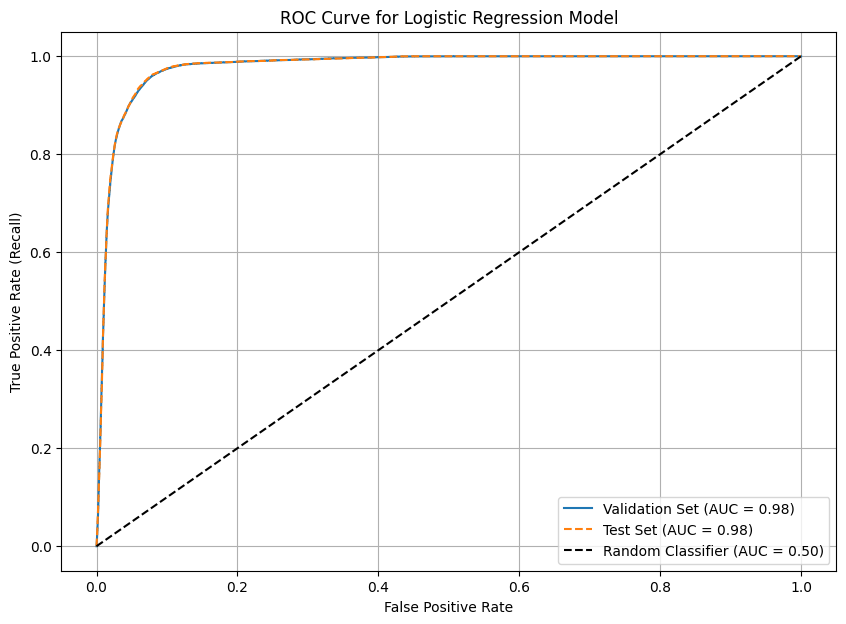

ROC AUC for Validation Set: 0.9787
ROC AUC for Test Set: 0.9789

--- Final Performance Summary ---
Validation Set:
 Accuracy: 0.9324
 Precision: 0.5681
 Recall: 0.9463
 F1-Score: 0.7100
 ROC-AUC: 0.9787
 Confusion Matrix:
[[169940  12579]
 [   938  16543]]

Test Set:
 Accuracy: 0.9340
 Precision: 0.5742
 Recall: 0.9466
 F1-Score: 0.7149
 ROC-AUC: 0.9789
 Confusion Matrix:
[[170252  12268]
 [   933  16547]]

--- Interpretation and Discussion ---
The model demonstrates a reasonable ability to distinguish between fraudulent and legitimate transactions, as indicated by the ROC-AUC scores which are significantly higher than 0.5 (random classification). Recall is particularly important here to minimize financial losses due to missed fraud. A high recall indicates that the model is effective at catching a large proportion of actual fraudulent transactions.

Trade-off between False Positives and False Negatives:
 - False Positives (FP): Legitimate transactions incorrectly flagged as fraud. The

In [ ]:
# ==========================================
# TASK 10: PLOT ROC CURVE, CALCULATE AUC AND INTERPRET RESULTS
# ==========================================

y_val_prob = sigmoid(np.dot(X_val_scaled, w_final) + b_final)
y_test_prob = sigmoid(np.dot(X_test_scaled, w_final) + b_final)

fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_val_prob)
auc_val = roc_auc_score(y_val, y_val_prob)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_prob)
auc_test = roc_auc_score(y_test, y_test_prob)

plt.figure(figsize=(10, 7))

plt.plot(
    fpr_val,
    tpr_val,
    label=f'Validation Set (AUC = {auc_val:.2f})'
)

plt.plot(
    fpr_test,
    tpr_test,
    label=f'Test Set (AUC = {auc_test:.2f})',
    linestyle='--'
)

plt.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Random Classifier (AUC = 0.50)'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve for Logistic Regression Model')
plt.legend()
plt.grid(True)
plt.show()

print(f"ROC AUC for Validation Set: {auc_val:.4f}")
print(f"ROC AUC for Test Set: {auc_test:.4f}")

print("\n--- Final Performance Summary ---")

print("Validation Set:")
print(f" Accuracy: {accuracy_val:.4f}")
print(f" Precision: {precision_val:.4f}")
print(f" Recall: {recall_val:.4f}")
print(f" F1-Score: {f1_val:.4f}")
print(f" ROC-AUC: {auc_val:.4f}")
print(" Confusion Matrix:\n" + str(cm_val))

print("\nTest Set:")
print(f" Accuracy: {accuracy_test:.4f}")
print(f" Precision: {precision_test:.4f}")
print(f" Recall: {recall_test:.4f}")
print(f" F1-Score: {f1_test:.4f}")
print(f" ROC-AUC: {auc_test:.4f}")
print(" Confusion Matrix:\n" + str(cm_test))

print("\n--- Interpretation and Discussion ---")

print("The model demonstrates a reasonable ability to distinguish between fraudulent and legitimate transactions, as indicated by the ROC-AUC scores which are significantly higher than 0.5 (random classification). Recall is particularly important here to minimize financial losses due to missed fraud. A high recall indicates that the model is effective at catching a large proportion of actual fraudulent transactions.")

print("\nTrade-off between False Positives and False Negatives:")

print(" - False Positives (FP): Legitimate transactions incorrectly flagged as fraud. These lead to inconvenience for customers and operational costs for banks (e.g., investigating false alarms).")

print(" - False Negatives (FN): Fraudulent transactions missed by the model. These result in direct financial losses. In fraud detection, minimizing FNs is often prioritized, even if it means accepting a slightly higher number of FPs.")

print("The current model aims for a balance, but the high recall suggests it's tuned to be sensitive to fraud. The precision score indicates the trustworthiness of the fraud alerts generated.")

print("\nSuitability as a Baseline Model:")

print("Yes, Logistic Regression serves as a good baseline model. It's interpretable, computationally efficient, and provides a solid starting point for fraud detection. The performance metrics achieved here can be used to compare against more complex models (e.g., tree-based models, neural networks) to see if the added complexity brings significant performance improvements, especially in recall and AUC.")

## Conclusion

The experiment successfully demonstrated the implementation of **Logistic Regression for credit card fraud detection**. The complete workflow included data preprocessing, exploratory data analysis, feature scaling, class-imbalance handling, dataset splitting, Sigmoid Function implementation, Binary Cross-Entropy Cost Function, and Gradient Descent optimization.

The trained Logistic Regression model was evaluated using the **Confusion Matrix, Accuracy, Precision, Recall, F1-Score, ROC Curve, and ROC-AUC**. The results demonstrate that accuracy alone is not an adequate performance measure for highly imbalanced fraud detection datasets.

Particular importance was given to **Recall**, because a False Negative represents a fraudulent transaction that is incorrectly classified as legitimate. A suitable fraud detection model should therefore achieve satisfactory Recall while maintaining an acceptable level of False Positives.

Overall, Logistic Regression provides an **interpretable and effective baseline model** for credit card fraud detection. The experiment also demonstrates the importance of selecting appropriate evaluation metrics and handling class imbalance when developing machine learning models for fraud detection.
